# IMPORTING THE LIBRARIES

In [11]:
import os
import pandas as pd
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from keras.models import Sequential
from keras.utils import plot_model, to_categorical
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from keras.preprocessing import image
from tqdm import tqdm


In [12]:
# Pretty display for notebooks
%matplotlib inline

# Defining the train,test and model directories

We will create the directories for train,test and model training paths if not present

In [13]:
BASE_PATH = r"E:\Data\imgs"

# Define the directories
TEST_DIR = os.path.join(BASE_PATH, "test")
TRAIN_DIR = os.path.join(BASE_PATH, "train")
MODEL_PATH = os.path.join(os.getcwd(),"model","self_trained")
PICKLE_DIR = os.path.join(os.getcwd(),"pickle_files")
CSV_DIR = os.path.join(os.getcwd(),"csv_files")

In [14]:
if not os.path.exists(TEST_DIR):
    print("Testing data does not exists")
if not os.path.exists(TRAIN_DIR):
    print("Training data does not exists")
if not os.path.exists(MODEL_PATH):
    print("Model path does not exists")
    os.makedirs(MODEL_PATH)
    print("Model path created")
if not os.path.exists(PICKLE_DIR):
    os.makedirs(PICKLE_DIR)
if not os.path.exists(CSV_DIR):
    os.makedirs(CSV_DIR)

# Data Preparation

We will create a csv file having the location of the files present for training and test images and their associated class if present so that it is easily traceable.

In [16]:
import os
import pandas as pd

def create_csv(DATA_DIR, filename):
    class_names = os.listdir(DATA_DIR)  # List all entries in DATA_DIR
    data = list()

    # Check if the first entry is a directory (for training data with class subfolders)
    if os.path.isdir(os.path.join(DATA_DIR, class_names[0])):
        # Iterate over each class subdirectory (c0, c1, ..., c9)
        for class_name in class_names:
            class_dir = os.path.join(DATA_DIR, class_name)
            # List all files in the class subdirectory
            file_names = os.listdir(class_dir)
            for file in file_names:
                # Append file path and class name to the data list
                data.append({
                    "Filename": os.path.join(DATA_DIR, class_name, file),
                    "ClassName": class_name
                })
    else:
        # If there are no subdirectories, treat this as test data
        class_name = "test"
        file_names = os.listdir(DATA_DIR)
        for file in file_names:
            # Append file path and assign "test" as the class name
            data.append({
                "Filename": os.path.join(DATA_DIR, file),
                "ClassName": class_name
            })

    # Convert list of dictionaries to a DataFrame
    data = pd.DataFrame(data)

    # Ensure the csv_files directory exists
    os.makedirs(os.path.join(os.getcwd(), "csv_files"), exist_ok=True)

    # Save DataFrame to CSV
    data.to_csv(os.path.join(os.getcwd(), "csv_files", filename), index=False)

# Example usage
TRAIN_DIR = "E:\\Data\\imgs\\train"
TEST_DIR = "E:\\Data\\imgs\\test"

# Create CSV for training data (subfolders c0 to c9)
create_csv(TRAIN_DIR, "train.csv")

# Create CSV for test data (no subfolders, all files are labeled as 'test')
create_csv(TEST_DIR, "test.csv")

# Load the generated CSV files into DataFrames
data_train = pd.read_csv(os.path.join(os.getcwd(), "csv_files", "train.csv"))
data_test = pd.read_csv(os.path.join(os.getcwd(), "csv_files", "test.csv"))


In [17]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22424 entries, 0 to 22423
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Filename   22424 non-null  object
 1   ClassName  22424 non-null  object
dtypes: object(2)
memory usage: 350.5+ KB


In [18]:
data_train['ClassName'].value_counts()

ClassName
c0    2489
c3    2346
c4    2326
c6    2325
c2    2317
c5    2312
c1    2267
c9    2129
c7    2002
c8    1911
Name: count, dtype: int64

In [19]:
data_train.describe()

,Filename,ClassName
count,22424,22424
unique,22424,10
top,E:\Data\imgs\train\c0\img_100026.jpg,c0
freq,1,2489


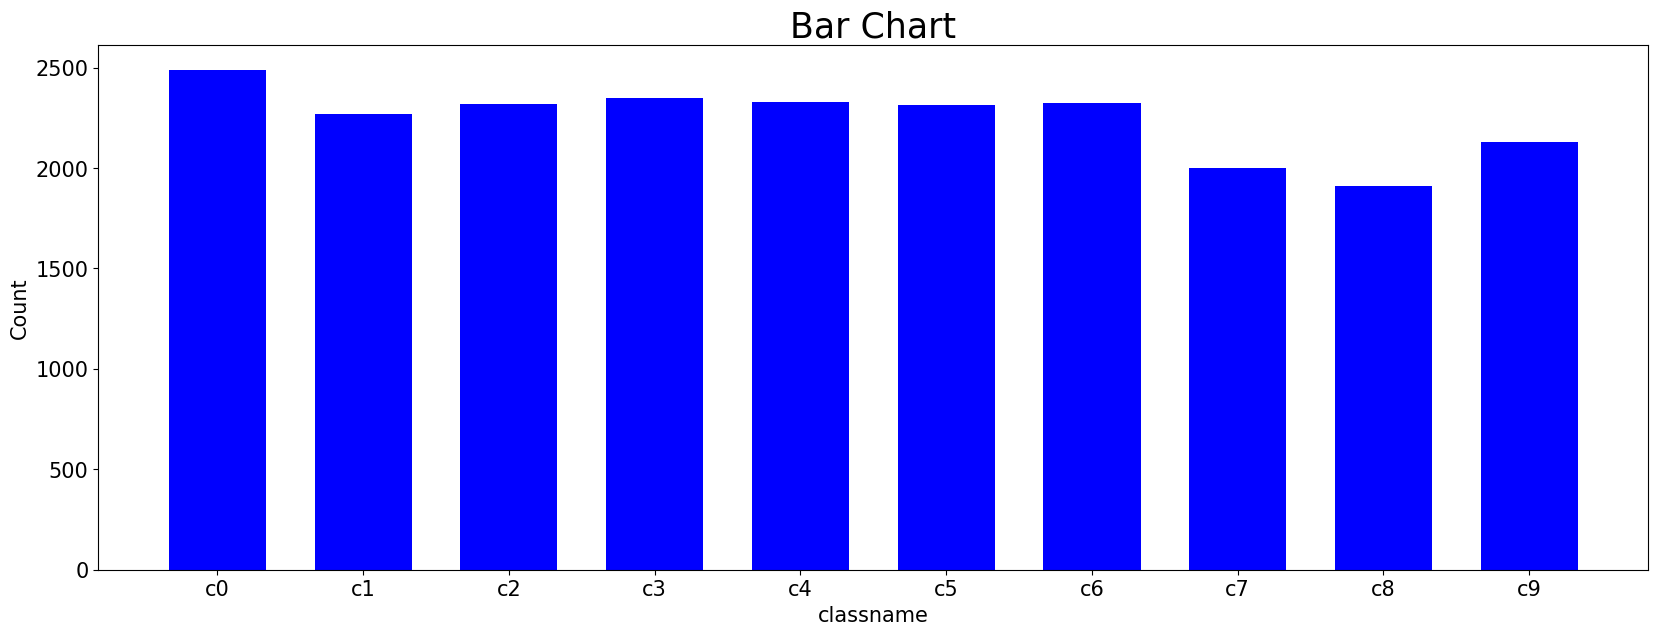

In [20]:


nf = data_train['ClassName'].value_counts(sort=False)
labels = data_train['ClassName'].value_counts(sort=False).index.tolist()
y = np.array(nf)
width = 1/1.5
N = len(y)
x = range(N)

fig = plt.figure(figsize=(20,15))
ay = fig.add_subplot(211)

plt.xticks(x, labels, size=15)
plt.yticks(size=15)

ay.bar(x, y, width, color="blue")

plt.title('Bar Chart',size=25)
plt.xlabel('classname',size=15)
plt.ylabel('Count',size=15)

plt.show()

In [21]:
data_test.head()

,Filename,ClassName
0,E:\Data\imgs\test\img_1.jpg,test
1,E:\Data\imgs\test\img_10.jpg,test
2,E:\Data\imgs\test\img_100.jpg,test
3,E:\Data\imgs\test\img_1000.jpg,test
4,E:\Data\imgs\test\img_100000.jpg,test


In [22]:
data_test.shape

(79726, 2)

## Observation:
1. There are total 22424 training samples
2. There are total 79726 training samples
3. The training dataset is equally balanced to a great extent and hence we need not do any downsampling of the data

## Converting into numerical values

In [23]:
labels_list = list(set(data_train['ClassName'].values.tolist()))
labels_id = {label_name:id for id,label_name in enumerate(labels_list)}
print(labels_id)
data_train['ClassName'].replace(labels_id,inplace=True)

{'c0': 0, 'c4': 1, 'c3': 2, 'c1': 3, 'c6': 4, 'c9': 5, 'c7': 6, 'c8': 7, 'c5': 8, 'c2': 9}


C:\Users\tharu\AppData\Local\Temp\ipykernel_10420\1324950157.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_train['ClassName'].replace(labels_id,inplace=True)
C:\Users\tharu\AppData\Local\Temp\ipykernel_10420\1324950157.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_train['ClassN

In [24]:
with open(os.path.join(os.getcwd(),"pickle_files","labels_list.pkl"),"wb") as handle:
    pickle.dump(labels_id,handle)

In [25]:
labels = to_categorical(data_train['ClassName'])
print(labels.shape)

(22424, 10)


## Splitting into Train and Test sets

In [26]:
from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest = train_test_split(data_train.iloc[:,0],labels,test_size = 0.2,random_state=42)

### Converting into 64*64 images 
You can substitute 64,64 to 224,224 for better results only if ram is >32gb

In [ ]:

def path_to_tensor(img_path):
    # loads RGB image as PIL.Image.Image type
    img = image.load_img(img_path, target_size=(64, 64))
    # convert PIL.Image.Image type to 3D tensor with shape (224, 224, 3)
    x = image.img_to_array(img)
    # convert 3D tensor to 4D tensor with shape (1, 224, 224, 3) and return 4D tensor
    return np.expand_dims(x, axis=0)

def paths_to_tensor(img_paths):
    list_of_tensors = [path_to_tensor(img_path) for img_path in tqdm(img_paths)]
    return np.vstack(list_of_tensors)

In [28]:

from PIL import ImageFile
from tensorflow.keras.preprocessing import image as tf_image


ImageFile.LOAD_TRUNCATED_IMAGES = True                 
def path_to_tensor(img_path):
    img = tf_image.load_img(img_path, target_size=(64, 64))
    x = tf_image.img_to_array(img)
    return np.expand_dims(x, axis=0)

def paths_to_tensor(img_paths):
    list_of_tensors = [path_to_tensor(img_path) for img_path in tqdm(img_paths)]
    return np.vstack(list_of_tensors)

# pre-process the data for Keras
train_tensors = paths_to_tensor(xtrain).astype('float32')/255 - 0.5


100%|██████████| 17939/17939 [00:43<00:00, 412.45it/s]


In [29]:
valid_tensors = paths_to_tensor(xtest).astype('float32')/255 - 0.5


100%|██████████| 4485/4485 [00:10<00:00, 417.26it/s]


# Defining the Model

In [ ]:
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=2, padding='same', activation='relu', input_shape=(64,64,3), kernel_initializer='glorot_normal'))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=128, kernel_size=2, padding='same', activation='relu', kernel_initializer='glorot_normal'))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=256, kernel_size=2, padding='same', activation='relu', kernel_initializer='glorot_normal'))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=512, kernel_size=2, padding='same', activation='relu', kernel_initializer='glorot_normal'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(500, 4 Convolutional Layers with increasing filter sizes: 64 → 128 → 256 → 512.
4 MaxPooling Layers for downsampling.
2 Dropout Layers to prevent overfitting.
1 Flatten Layer to reshape the feature map into a 1D vector.
2 Dense Layersactivation='relu', kernel_initializer='glorot_normal'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax', kernel_initializer='glorot_normal'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 64)        832       
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 64)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 128)       32896     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 128)       0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 256)       131328    
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 8, 8, 256)         0

In [32]:
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

In [33]:
filepath = os.path.join(MODEL_PATH,"distracted-{epoch:02d}-{val_accuracy:.2f}.hdf5")
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max',period=1)
callbacks_list = [checkpoint]

In [34]:
model_history = model.fit(train_tensors,ytrain,validation_data = (valid_tensors, ytest),epochs=25, batch_size=40, shuffle=True,callbacks=callbacks_list)

Epoch 1/25
449/449 [==============================] - ETA: 0s - loss: 1.1070 - accuracy: 0.6068
Epoch 1: val_accuracy improved from -inf to 0.89208, saving model to e:\Distracted-Driver-Detection-Using-Deep-Learning-main\Training Notebooks\model\self_trained\distracted-01-0.89.hdf5
449/449 [==============================] - 132s 291ms/step - loss: 1.1070 - accuracy: 0.6068 - val_loss: 0.3251 - val_accuracy: 0.8921
Epoch 2/25


c:\Users\tharu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


449/449 [==============================] - ETA: 0s - loss: 0.2704 - accuracy: 0.9191
Epoch 2: val_accuracy improved from 0.89208 to 0.97369, saving model to e:\Distracted-Driver-Detection-Using-Deep-Learning-main\Training Notebooks\model\self_trained\distracted-02-0.97.hdf5
449/449 [==============================] - 151s 337ms/step - loss: 0.2704 - accuracy: 0.9191 - val_loss: 0.1048 - val_accuracy: 0.9737
Epoch 3/25
449/449 [==============================] - ETA: 0s - loss: 0.1362 - accuracy: 0.9601
Epoch 3: val_accuracy did not improve from 0.97369
449/449 [==============================] - 149s 331ms/step - loss: 0.1362 - accuracy: 0.9601 - val_loss: 0.1677 - val_accuracy: 0.9447
Epoch 4/25
449/449 [==============================] - ETA: 0s - loss: 0.0866 - accuracy: 0.9745
Epoch 4: val_accuracy improved from 0.97369 to 0.98751, saving model to e:\Distracted-Driver-Detection-Using-Deep-Learning-main\Training Notebooks\model\self_trained\distracted-04-0.99.hdf5
449/449 [=============

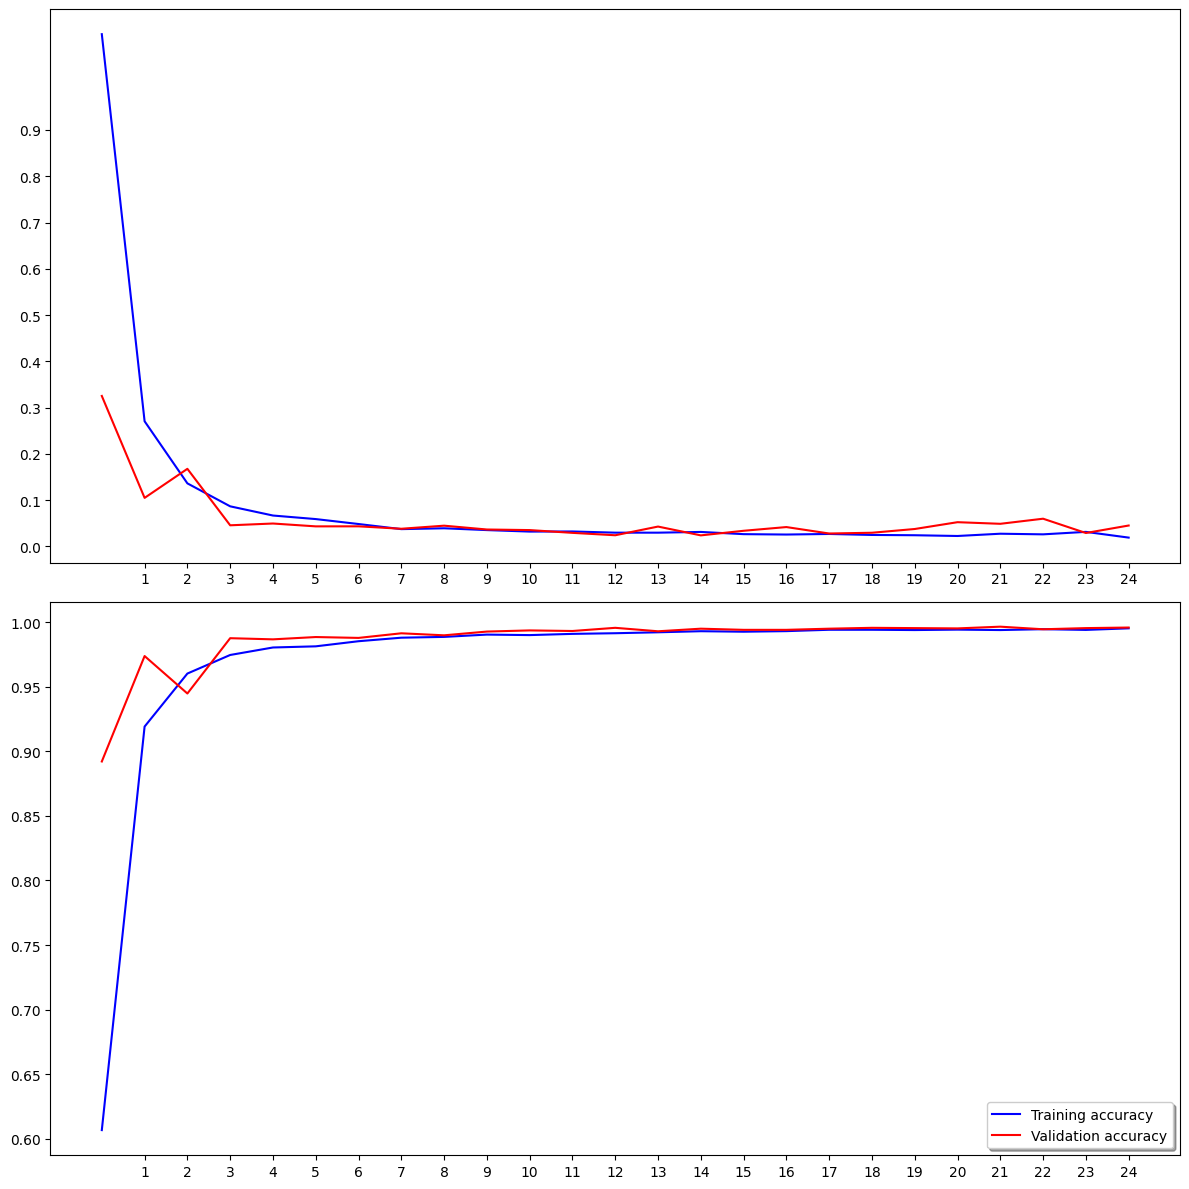

In [35]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
ax1.plot(model_history.history['loss'], color='b', label="Training loss")
ax1.plot(model_history.history['val_loss'], color='r', label="validation loss")
ax1.set_xticks(np.arange(1, 25, 1))
ax1.set_yticks(np.arange(0, 1, 0.1))

ax2.plot(model_history.history['accuracy'], color='b', label="Training accuracy")
ax2.plot(model_history.history['val_accuracy'], color='r',label="Validation accuracy")
ax2.set_xticks(np.arange(1, 25, 1))

legend = plt.legend(loc='best', shadow=True)
plt.tight_layout()
plt.show()

# Model Analysis

Finding the Confusion matrix,Precision,Recall and F1 score to analyse the model thus created 

In [36]:

def print_confusion_matrix(confusion_matrix, class_names, figsize = (10,7), fontsize=14):
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names, 
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig.savefig(os.path.join(MODEL_PATH,"confusion_matrix.png"))
    return fig


In [37]:
def print_heatmap(n_labels, n_predictions, class_names):
    labels = n_labels #sess.run(tf.argmax(n_labels, 1))
    predictions = n_predictions #sess.run(tf.argmax(n_predictions, 1))

#     confusion_matrix = sess.run(tf.contrib.metrics.confusion_matrix(labels, predictions))
    matrix = confusion_matrix(labels.argmax(axis=1),predictions.argmax(axis=1))
    row_sum = np.sum(matrix, axis = 1)
    w, h = matrix.shape

    c_m = np.zeros((w, h))

    for i in range(h):
        c_m[i] = matrix[i] * 100 / row_sum[i]

    c = c_m.astype(dtype = np.uint8)

    
    heatmap = print_confusion_matrix(c, class_names, figsize=(18,10), fontsize=20)


In [38]:
class_names = list()
for name,idx in labels_id.items():
    class_names.append(name)
# print(class_names)
ypred = model.predict(valid_tensors)

141/141 [==============================] - 7s 46ms/step


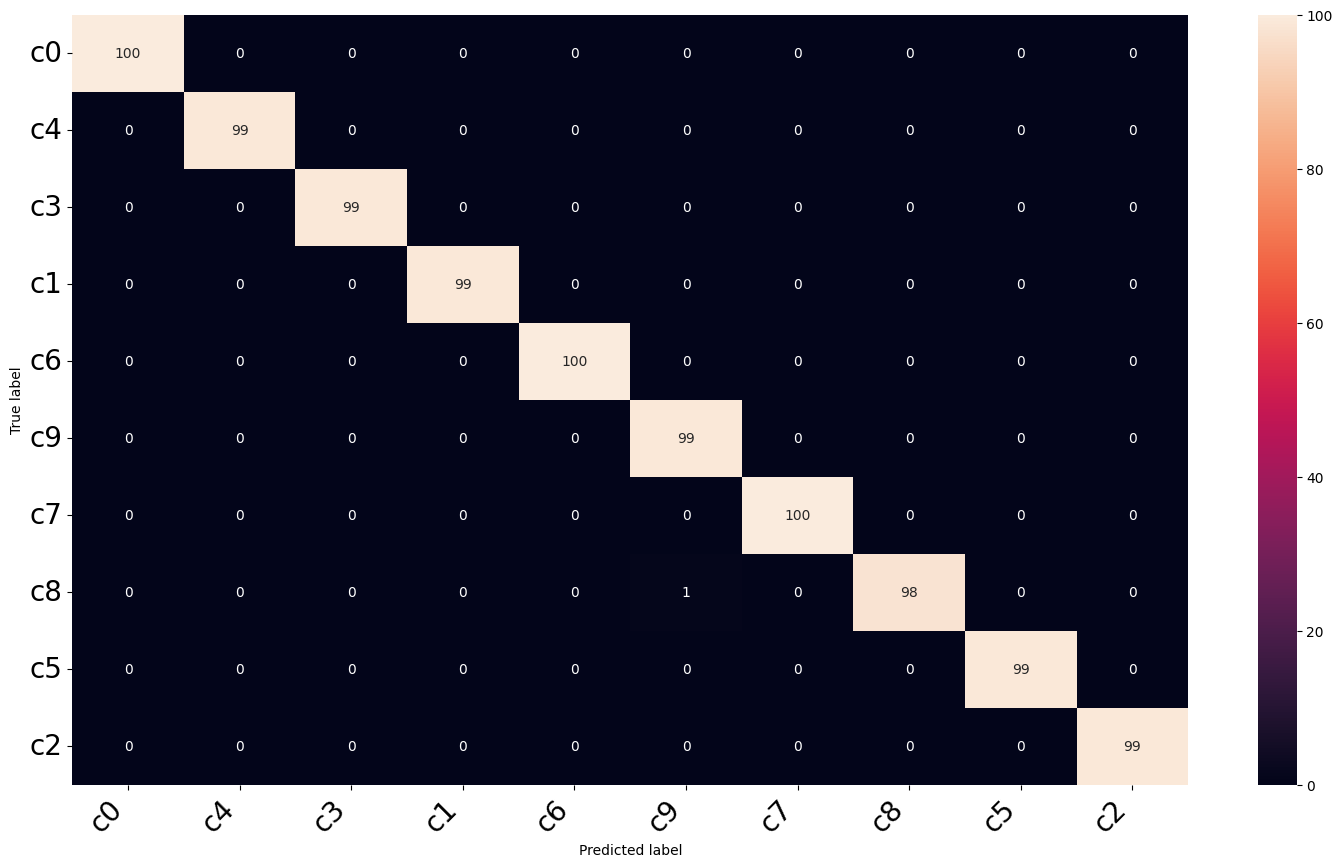

In [39]:
print_heatmap(ytest,ypred,class_names)

## Precision Recall F1 Score

In [40]:
ypred_class = np.argmax(ypred,axis=1)
# print(ypred_class[:10])
ytest = np.argmax(ytest,axis=1)

In [41]:
accuracy = accuracy_score(ytest,ypred_class)
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(ytest, ypred_class,average='weighted')
print('Precision: %f' % precision)
# recall: tp / (tp + fn)
recall = recall_score(ytest,ypred_class,average='weighted')
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(ytest,ypred_class,average='weighted')
print('F1 score: %f' % f1)

Accuracy: 0.995764
Precision: 0.995781
Recall: 0.995764
F1 score: 0.995762
